In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:
# Running in local offline workstation environment
IN_COLAB = False
print("Running on local workstation. Repositories and paths are assumed local.")

Running on local workstation. Repositories and paths are assumed local.


In [3]:
# Ensure you have installed these packages in your environment (e.g. conda environment):
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install "transformers>=5.0.0" peft trl datasets accelerate bitsandbytes matplotlib seaborn jupyterlab ipykernel
print("Please verify packages are pre-installed in your virtual environment.")

Looking in indexes: https://download.pytorch.org/whl/cu121
Please verify packages are pre-installed in your virtual environment.


In [2]:
import os
import sys
import json
import torch
import random

# Establish seeds for training reproducibility
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

CUDA Available: True
Device Name: NVIDIA A100-PCIE-40GB


In [3]:
PERSISTENT_DIR = "./outputs"
os.makedirs(PERSISTENT_DIR, exist_ok=True)
print(f"Target checkpoints directory configured locally: {PERSISTENT_DIR}")

Target checkpoints directory configured locally: ./outputs


In [4]:
import gc

def clear_gpu_memory():
    """Purges system garbage collection and releases cached PyTorch CUDA memory."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print("Released GPU cache memory.")

clear_gpu_memory()

Released GPU cache memory.


In [14]:
import os
import json
from huggingface_hub import HfApi, hf_hub_download
from datasets import Dataset
from transformers import AutoTokenizer

repo_id = "upwitu/trash_draft_am"
MODEL_NAME = "Qwen/Qwen3.5-4B"

print("Initializing tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

all_samples = []
try:
    print(f"Scanning files in repo '{repo_id}'...")
    api = HfApi()
    files = api.list_repo_files(repo_id=repo_id, repo_type="dataset")
    
    jsonl_files = [f for f in files if f.endswith(".jsonl")]
    if not jsonl_files:
        raise FileNotFoundError("No .jsonl files found in the Hugging Face repository.")
        
    print(f"Found data files: {jsonl_files}")
    
    for target_file in jsonl_files:
        print(f"Downloading file '{target_file}'...")
        local_file_path = hf_hub_download(repo_id=repo_id, filename=target_file, repo_type="dataset")
        
        file_samples = 0
        skipped_samples = 0
        error_logs_printed = 0
        is_augmented_task = "hallucination" in target_file or "disambiguation" in target_file
        
        with open(local_file_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    messages = None
                    try:
                        sample = json.loads(line)
                        if is_augmented_task:
                            messages = sample.get("augmented_messages") or sample.get("raw_messages")
                        else:
                            messages = sample.get("raw_messages") or sample.get("augmented_messages")
                            
                        if not messages:
                            messages = sample.get("messages")
                            
                        if messages:
                            # Apply the Qwen chat template
                            text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
                            all_samples.append({"text": text})
                            file_samples += 1
                        else:
                            skipped_samples += 1
                            if error_logs_printed < 3:
                                print(f"Skipped in {target_file}: No valid messages key found. Keys: {list(sample.keys())}")
                                error_logs_printed += 1
                    except Exception as e:
                        skipped_samples += 1
                        if error_logs_printed < 3:
                            print(f"Template error in {target_file}: {e}")
                            # Print a snippet of the message causing the issue
                            print(f"Problematic message structure: {str(messages)[:300]}...")
                            error_logs_printed += 1
                        continue
                        
        print(f"Loaded {file_samples} samples from '{target_file}' (Skipped/Failed: {skipped_samples}).")

except Exception as e:
    print(f"Error loading files: {e}")

if all_samples:
    dataset = Dataset.from_list(all_samples)
    print("\n" + "="*40)
    print("Dataset initialized successfully!")
    print(f"Total valid SFT samples: {len(dataset)}")
    print("Dataset columns:", dataset.column_names)
    print("First SFT sample preview:\n", dataset[0]["text"][:300] + "...")
    print("="*40)
    
    dataset_split = dataset.train_test_split(test_size=0.1, seed=42)
    train_dataset = dataset_split["train"]
    eval_dataset = dataset_split["test"]
    print(f"Dataset split: {len(train_dataset)} train samples, {len(eval_dataset)} eval samples.")
else:
    print("Error: Failed to format any SFT samples.")

Initializing tokenizer...
Scanning files in repo 'upwitu/trash_draft_am'...
Found data files: ['data/interactive_agent_disambiguation.jsonl', 'data/interactive_agent_hallucination.jsonl', 'data/search_disambiguation.jsonl', 'data/search_hallucination.jsonl']
Template error in data/interactive_agent_disambiguation.jsonl: Can only get item pairs from a mapping.
Problematic message structure: [{'role': 'system', 'content': 'You are a customer service agent that helps the user.  The policy that determines how you should respond to requests from users is described below between the <policy> and </policy> tags.\n\nIn each turn you can either:\n- Send a message to the user.\n- Make a tool ca...
Template error in data/interactive_agent_disambiguation.jsonl: Can only get item pairs from a mapping.
Problematic message structure: [{'role': 'system', 'content': 'You are a customer service agent that helps the user.  The policy that determines how you should respond to requests from users is descri

In [15]:
if "text" in train_dataset.column_names:
    formatted_train_dataset = train_dataset
    formatted_eval_dataset = eval_dataset
    print("Dữ liệu đã có sẵn cột 'text' được định dạng trước. Bỏ qua bước mapping.")
    print("\nVí dụ mẫu văn bản SFT (Train):")
    print(formatted_train_dataset[0]['text'][:500] + "...")
else:
    def format_sft_data(examples):
        formatted_texts = []
        for prompt, chosen in zip(examples["prompt"], examples["chosen"]):
            messages = prompt + chosen
            text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
            formatted_texts.append(text)
        return {"text": formatted_texts}
        
    formatted_train_dataset = train_dataset.map(format_sft_data, batched=True)
    formatted_eval_dataset = eval_dataset.map(format_sft_data, batched=True) if len(eval_dataset) > 0 else None
    print("Ví dụ mẫu văn bản SFT (Train):")
    print(formatted_train_dataset[0]['text'][:500] + "...")

Dữ liệu đã có sẵn cột 'text' được định dạng trước. Bỏ qua bước mapping.

Ví dụ mẫu văn bản SFT (Train):
<|im_start|>system
You are an expert search agent. Your goal is to answer the user's question efficiently using verifiable online sources.

Execution Rules:
1. ** Seach Results ** - Each search query returns 10 detailed results or sources. Use as many tool calls as required but do not spam searches.
2. ** Planning ** - Start by breaking the problem into multiple key sub-questions (as many as required only). If you aren't confident about something, break it down into smaller sub-questions.
2. ** ...



   PHÂN TÍCH ĐỘ DÀI TOKEN: TRAIN DATASET
Tổng số mẫu phân tích : 23472
Độ dài lớn nhất (Max) : 1708 tokens
Độ dài nhỏ nhất (Min) : 291 tokens
Độ dài trung bình    : 760.36 tokens
Độ dài trung vị      : 899.0 tokens
Phân vị 95% (p95)    : 1183.0 tokens
Phân vị 99% (p99)    : 1323.0 tokens
-----------------------------------------
Tuyệt vời: Tất cả các mẫu đều nằm dưới ngưỡng 2048 tokens.


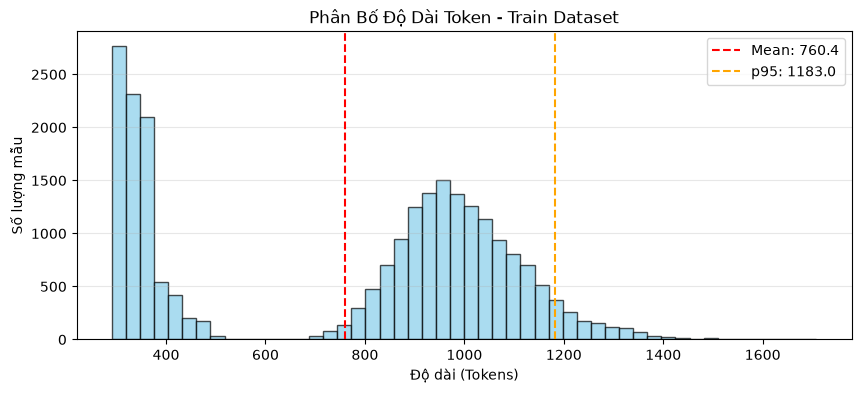

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_dataset_token_lengths(dataset, name="Dataset"):
    print(f"\n=========================================")
    print(f"   PHÂN TÍCH ĐỘ DÀI TOKEN: {name.upper()}")
    print(f"=========================================")
    
    lengths = []
    
    # Lặp qua từng mẫu và đếm số lượng token thực tế
    for idx, example in enumerate(dataset):
        # Encode không giới hạn chiều dài để đo độ dài thực tế
        input_ids = tokenizer.encode(example["text"], add_special_tokens=False)
        lengths.append(len(input_ids))
        
    lengths = np.array(lengths)
    
    # Tính toán các chỉ số thống kê
    max_len = np.max(lengths)
    min_len = np.min(lengths)
    mean_len = np.mean(lengths)
    median_len = np.median(lengths)
    p95 = np.percentile(lengths, 95)
    p99 = np.percentile(lengths, 99)
    
    print(f"Tổng số mẫu phân tích : {len(lengths)}")
    print(f"Độ dài lớn nhất (Max) : {max_len} tokens")
    print(f"Độ dài nhỏ nhất (Min) : {min_len} tokens")
    print(f"Độ dài trung bình    : {mean_len:.2f} tokens")
    print(f"Độ dài trung vị      : {median_len:.1f} tokens")
    print(f"Phân vị 95% (p95)    : {p95:.1f} tokens")
    print(f"Phân vị 99% (p99)    : {p99:.1f} tokens")
    print(f"-----------------------------------------")
    
    # Kiểm tra tỷ lệ vượt ngưỡng 2048 (ngưỡng max_length mặc định của bạn)
    limit = 2048
    over_limit = np.sum(lengths > limit)
    if over_limit > 0:
        pct = (over_limit / len(lengths)) * 100
        print(f"CẢNH BÁO: Có {over_limit} mẫu ({pct:.2f}%) dài hơn {limit} tokens!")
    else:
        print(f"Tuyệt vời: Tất cả các mẫu đều nằm dưới ngưỡng {limit} tokens.")
        
    # Vẽ biểu đồ phân bố độ dài nếu cần thiết
    plt.figure(figsize=(10, 4))
    plt.hist(lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    plt.axvline(mean_len, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean_len:.1f}')
    plt.axvline(p95, color='orange', linestyle='dashed', linewidth=1.5, label=f'p95: {p95:.1f}')
    plt.title(f"Phân Bố Độ Dài Token - {name}")
    plt.xlabel("Độ dài (Tokens)")
    plt.ylabel("Số lượng mẫu")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    
    return lengths

# Chạy phân tích trên tập dữ liệu train đã được định dạng
if 'formatted_train_dataset' in locals() and len(formatted_train_dataset) > 0:
    train_lengths = analyze_dataset_token_lengths(formatted_train_dataset, "Train Dataset")
else:
    print("Không tìm thấy biến formatted_train_dataset hoặc tập dữ liệu trống.")

In [17]:
import sys
import torch
import torch.utils

# 1. Vá PyTorch để giả lập các kiểu dữ liệu int1 -> int7
print("Đang áp dụng bản vá cho PyTorch...")
for i in range(1, 8):
    int_attr = f"int{i}"
    uint_attr = f"uint{i}"
    if not hasattr(torch, int_attr):
        setattr(torch, int_attr, torch.int8)
    if not hasattr(torch, uint_attr):
        setattr(torch, uint_attr, torch.uint8)

# 2. Vá hàm register_constant của torch.utils._pytree (Decorator rỗng) để tránh lỗi torchao
if not hasattr(torch.utils, "_pytree"):
    import torch.utils._pytree
if not hasattr(torch.utils._pytree, "register_constant"):
    # register_constant được dùng làm decorator, nên ta trả về decorator rỗng
    torch.utils._pytree.register_constant = lambda cls: cls
    print("Đã vá decorator register_constant của PyTorch.")

# 3. Khôi phục sys.modules của torchao
if "torchao" in sys.modules and sys.modules["torchao"] is None:
    del sys.modules["torchao"]

# 4. CHỈ import transformers trước
import transformers

# 5. VÁ NGAY LẬP TỨC transformers trước khi import peft
print("Đang vô hiệu hóa kiểm tra torchao trong transformers...")
transformers.utils.import_utils.is_torchao_available = lambda *args, **kwargs: False
transformers.utils.is_torchao_available = lambda *args, **kwargs: False
if hasattr(transformers.utils.import_utils, "_torchao_available"):
    transformers.utils.import_utils._torchao_available = False

# 6. BÂY GIỜ MỚI import peft (Sẽ an toàn vì transformers đã được vá)
import peft

# 7. Vá nốt peft
print("Đang vô hiệu hóa kiểm tra torchao trong peft...")
peft.import_utils.is_torchao_available = lambda *args, **kwargs: False
if hasattr(peft.tuners.lora.torchao, "is_torchao_available"):
    peft.tuners.lora.torchao.is_torchao_available = lambda *args, **kwargs: False

print("Đã vá toàn bộ thành công! Bắt đầu nạp mô hình...")

# 8. Cấu hình các thông số và nạp model
USE_UNSLOTH = False  
MAX_SEQ_LENGTH = 2048
MODEL_NAME = "Qwen/Qwen3.5-4B"

from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

print("Loading model via Standard HF PEFT in BF16...")

# Nạp mô hình gốc bằng kiểu dữ liệu BF16 tối ưu
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True
)

# Cấu hình LoRA adapter tương tự Unsloth
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, peft_config)

print("\nModel initialized. Trainable parameters:")
model.print_trainable_parameters()

Đang áp dụng bản vá cho PyTorch...
Đang vô hiệu hóa kiểm tra torchao trong transformers...
Đang vô hiệu hóa kiểm tra torchao trong peft...
Đã vá toàn bộ thành công! Bắt đầu nạp mô hình...
Loading model via Standard HF PEFT in BF16...


Loading weights: 100%|██████████████████████████████████████████████████████████████| 426/426 [00:01<00:00, 332.37it/s]



Model initialized. Trainable parameters:
trainable params: 21,233,664 || all params: 4,226,984,960 || trainable%: 0.5023


In [18]:
MAX_TOKEN_LIMIT = 1000

print(f"Filtering dataset to keep conversations below {MAX_TOKEN_LIMIT} tokens...")

def filter_by_token_length(examples):
    batch_tokens = tokenizer(examples["text"], add_special_tokens=False, truncation=False)
    return [len(ids) < MAX_TOKEN_LIMIT for ids in batch_tokens["input_ids"]]

train_before_len = len(train_dataset)
formatted_train_dataset = train_dataset.filter(filter_by_token_length, batched=True)

eval_before_len = 0
if eval_dataset is not None and len(eval_dataset) > 0:
    eval_before_len = len(eval_dataset)
    formatted_eval_dataset = eval_dataset.filter(filter_by_token_length, batched=True)

print("\n" + "="*40)
print(f"Filtering completed (limit: {MAX_TOKEN_LIMIT} tokens)")
print("="*40)
print(f"Train Dataset: reduced from {train_before_len} to {len(formatted_train_dataset)} samples.")
if eval_before_len > 0:
    print(f"Eval Dataset : reduced from {eval_before_len} to {len(formatted_eval_dataset)} samples.")
print("="*40)

Filtering dataset to keep conversations below 1000 tokens...


Filter: 100%|█████████████████████████████████████████████████████████████| 2608/2608 [00:00<00:00, 3454.83 examples/s]


Filtering completed (limit: 1000 tokens)
Train Dataset: reduced from 23472 to 16753 samples.
Eval Dataset : reduced from 2608 to 1806 samples.


In [19]:
LIMIT_TRAIN_SAMPLES = 2000

if len(formatted_train_dataset) > LIMIT_TRAIN_SAMPLES:
    print(f"Shuffling and selecting {LIMIT_TRAIN_SAMPLES} samples...")
    # Randomly shuffle with seed to ensure representative task distribution
    formatted_train_dataset = formatted_train_dataset.shuffle(seed=42).select(range(LIMIT_TRAIN_SAMPLES))
    print(f"Train Dataset updated to: {len(formatted_train_dataset)} samples.")
else:
    print(f"Train Dataset size ({len(formatted_train_dataset)}) is already less than or equal to {LIMIT_TRAIN_SAMPLES}, keeping original size.")

Shuffling and selecting 2000 samples...
Train Dataset updated to: 2000 samples.


In [20]:
from trl import SFTConfig

sft_config = SFTConfig(
    dataset_text_field="text",
    max_length=MAX_TOKEN_LIMIT,
    output_dir=PERSISTENT_DIR,
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    warmup_steps=10,
    fp16=False,
    bf16=True,
    optim="paged_adamw_8bit",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=5,
    report_to="none"
)

print("SFT configurations set successfully.")

SFT configurations set successfully.


In [1]:
import os
from trl import SFTTrainer

resume_checkpoint = None
if os.path.exists(PERSISTENT_DIR):
    checkpoints = [os.path.join(PERSISTENT_DIR, d) for d in os.listdir(PERSISTENT_DIR) if d.startswith("checkpoint-")]
    if checkpoints:
        checkpoints.sort(key=lambda x: int(x.split("-")[-1]))
        resume_checkpoint = checkpoints[-1]
        print(f"Found existing checkpoint: {resume_checkpoint}. Resuming from this step.")

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=formatted_train_dataset,
    eval_dataset=formatted_eval_dataset,
    processing_class=tokenizer
)

if len(formatted_train_dataset) > 0:
    print("Starting SFT training...")
    trainer_stats = trainer.train(resume_from_checkpoint=resume_checkpoint)
    print("Training completed successfully!")
else:
    print("Error: Train dataset is empty, training cannot start.")

/home/hungpv/miniconda3/envs/carbench_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.5.1+cu121).


RuntimeError: Failed to import trl.trainer.sft_trainer because of the following error (look up to see its traceback):
Could not import module 'AutoProcessor'. Are this object's requirements defined correctly?

In [2]:
ADAPTER_PATH = os.path.join(PERSISTENT_DIR, "sft_lora_adapter")
MERGED_PATH = os.path.join(PERSISTENT_DIR, "sft_merged_model")

# Save training adapter checkpoints
model.save_pretrained(ADAPTER_PATH)
tokenizer.save_pretrained(ADAPTER_PATH)
print(f"LoRA adapter weights saved to {ADAPTER_PATH}")

# Save merged weights (16-bit precision)
if USE_UNSLOTH:
    print("Saving merged 16-bit model weights via Unsloth...")
    model.save_pretrained_merged(MERGED_PATH, tokenizer, save_method="merged_16bit")
    print(f"Merged model saved to {MERGED_PATH}")
else:
    print("Merging standard HF PEFT model weights...")
    from peft import PeftModel
    from transformers import AutoModelForCausalLM
    
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.bfloat16,
        device_map="cpu",
        trust_remote_code=True
    )
    peft_model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
    merged_model = peft_model.merge_and_unload()
    
    merged_model.save_pretrained(MERGED_PATH)
    tokenizer.save_pretrained(MERGED_PATH)
    print(f"Merged model saved to {MERGED_PATH}")

NameError: name 'PERSISTENT_DIR' is not defined

In [5]:
%%writefile train.py
import os
import sys
import json
import torch
import torch.utils

# ==========================================
# 1. MONKEYPATCH PYTORCH, TORCHAO & HF SECURITY
# ==========================================
print("Applying PyTorch patches...")
for i in range(1, 8):
    int_attr = f"int{i}"
    uint_attr = f"uint{i}"
    if not hasattr(torch, int_attr):
        setattr(torch, int_attr, torch.int8)
    if not hasattr(torch, uint_attr):
        setattr(torch, uint_attr, torch.uint8)

if not hasattr(torch.utils, "_pytree"):
    import torch.utils._pytree
if not hasattr(torch.utils._pytree, "register_constant"):
    torch.utils._pytree.register_constant = lambda cls: cls
    print("Patched PyTorch register_constant.")

if "torchao" in sys.modules and sys.modules["torchao"] is None:
    del sys.modules["torchao"]

# Monkeypatch torch.load to bypass weights_only restrictions on local checkpoints
original_torch_load = torch.load
def patched_torch_load(*args, **kwargs):
    if "weights_only" in kwargs:
        kwargs["weights_only"] = False
    return original_torch_load(*args, **kwargs)
torch.load = patched_torch_load
print("Bypassed PyTorch torch.load weights_only restrictions.")

import transformers
print("Disabling torchao and safety block in transformers...")
transformers.utils.import_utils.is_torchao_available = lambda *args, **kwargs: False
transformers.utils.is_torchao_available = lambda *args, **kwargs: False
if hasattr(transformers.utils.import_utils, "_torchao_available"):
    transformers.utils.import_utils._torchao_available = False

# Direct monkeypatch for CVE-2025-32434 check in transformers to bypass torch.load restriction
import transformers.trainer
import transformers.utils.import_utils
import transformers.utils

bypass_safety = lambda *args, **kwargs: None
transformers.utils.import_utils.check_torch_load_is_safe = bypass_safety
transformers.utils.check_torch_load_is_safe = bypass_safety
transformers.trainer.check_torch_load_is_safe = bypass_safety
print("Bypassed transformers torch.load security checks.")

import peft
print("Disabling torchao in peft...")
peft.import_utils.is_torchao_available = lambda *args, **kwargs: False
if hasattr(peft.tuners.lora.torchao, "is_torchao_available"):
    peft.tuners.lora.torchao.is_torchao_available = lambda *args, **kwargs: False

# ==========================================
# 2. NOW SAFE TO IMPORT OTHER LIBRARIES
# ==========================================
print("Importing core SFT libraries...")
from huggingface_hub import HfApi, hf_hub_download
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import SFTTrainer, SFTConfig
from peft import LoraConfig, get_peft_model
import wandb

# ==========================================
# 3. CONFIGURATION & GPU SETUP
# ==========================================
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
PERSISTENT_DIR = "./outputs"
MODEL_NAME = "Qwen/Qwen3.5-4B"
MAX_TOKEN_LIMIT = 1000
LIMIT_TRAIN_SAMPLES = 5000

# ==========================================
# 4. INITIALIZE WANDB
# ==========================================
print("Initializing wandb...")
wandb.init(
    project="carbench-sft", 
    name="qwen3.5-4b-sft-5k",
    config={
        "model": MODEL_NAME,
        "max_length": MAX_TOKEN_LIMIT,
        "train_samples": LIMIT_TRAIN_SAMPLES,
    }
)

# ==========================================
# 5. LOAD & PREPARE DATASET
# ==========================================
print("Initializing tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

repo_id = "upwitu/trash_draft_am"
all_samples = []

try:
    print(f"Scanning files in repo '{repo_id}'...")
    api = HfApi()
    files = api.list_repo_files(repo_id=repo_id, repo_type="dataset")
    jsonl_files = [f for f in files if f.endswith(".jsonl")]
    
    for target_file in jsonl_files:
        print(f"Downloading file '{target_file}'...")
        local_file_path = hf_hub_download(repo_id=repo_id, filename=target_file, repo_type="dataset")
        
        file_samples = 0
        is_augmented_task = "hallucination" in target_file or "disambiguation" in target_file
        
        with open(local_file_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        sample = json.loads(line)
                        if is_augmented_task:
                            messages = sample.get("augmented_messages") or sample.get("raw_messages")
                        else:
                            messages = sample.get("raw_messages") or sample.get("augmented_messages")
                            
                        if not messages:
                            messages = sample.get("messages")
                            
                        if messages:
                            text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
                            all_samples.append({"text": text})
                            file_samples += 1
                    except Exception:
                        continue
        print(f"Loaded {file_samples} samples from '{target_file}'.")
except Exception as e:
    print(f"Error loading files: {e}")
    sys.exit(1)

dataset = Dataset.from_list(all_samples)
dataset_split = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = dataset_split["train"]
eval_dataset = dataset_split["test"]

# Apply Length Filtering (< 1000 tokens)
def filter_by_token_length(examples):
    batch_tokens = tokenizer(examples["text"], add_special_tokens=False, truncation=False)
    return [len(ids) < MAX_TOKEN_LIMIT for ids in batch_tokens["input_ids"]]

print(f"Filtering dataset below {MAX_TOKEN_LIMIT} tokens...")
formatted_train_dataset = train_dataset.filter(filter_by_token_length, batched=True)
formatted_eval_dataset = eval_dataset.filter(filter_by_token_length, batched=True)

# Select random 5k subset
if len(formatted_train_dataset) > LIMIT_TRAIN_SAMPLES:
    print(f"Selecting random {LIMIT_TRAIN_SAMPLES} samples...")
    formatted_train_dataset = formatted_train_dataset.shuffle(seed=42).select(range(LIMIT_TRAIN_SAMPLES))

print(f"Final dataset: Train={len(formatted_train_dataset)}, Eval={len(formatted_eval_dataset)}")

# ==========================================
# 6. MODEL & LORA INITIALIZATION
# ==========================================
print("Loading causal LLM...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True
)

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, peft_config)
print("Model and adapters initialized successfully.")

# ==========================================
# 7. TRAINING CONFIGURATION & RUN
# ==========================================
resume_checkpoint = None
if os.path.exists(PERSISTENT_DIR):
    checkpoints = [os.path.join(PERSISTENT_DIR, d) for d in os.listdir(PERSISTENT_DIR) if d.startswith("checkpoint-")]
    if checkpoints:
        checkpoints.sort(key=lambda x: int(x.split("-")[-1]))
        resume_checkpoint = checkpoints[-1]
        print(f"Resuming from checkpoint: {resume_checkpoint}")

sft_config = SFTConfig(
    dataset_text_field="text",
    max_length=MAX_TOKEN_LIMIT,
    output_dir=PERSISTENT_DIR,
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    warmup_steps=10,
    fp16=False,
    bf16=True,
    optim="paged_adamw_8bit",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=5,
    report_to="wandb",
    run_name="qwen3.5_4b_sft_5k"
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=formatted_train_dataset,
    eval_dataset=formatted_eval_dataset,
    processing_class=tokenizer
)

print("Starting training...")
trainer.train(resume_from_checkpoint=resume_checkpoint)
print("Training completed.")

# ==========================================
# 8. SAVE & MERGE WEIGHTS
# ==========================================
# 1. Save final adapter weights
ADAPTER_PATH = os.path.join(PERSISTENT_DIR, "sft_lora_adapter")
model.save_pretrained(ADAPTER_PATH)
tokenizer.save_pretrained(ADAPTER_PATH)
print(f"LoRA adapters successfully saved to {ADAPTER_PATH}")

# 2. Merge LoRA weights with base model and save fully merged model
print("Merging LoRA adapters with base model...")
merged_model = model.merge_and_unload()
MERGED_PATH = os.path.join(PERSISTENT_DIR, "sft_merged_model")
merged_model.save_pretrained(MERGED_PATH, safe_serialization=True)
tokenizer.save_pretrained(MERGED_PATH)
print(f"Merged model successfully saved to {MERGED_PATH}")

wandb.finish()

Overwriting train.py


In [2]:
%%writefile scenarios/track_1_agent_under_test/eval_custom_sft.toml
# Custom test-set evaluation configuration for the SFT Qwen model

[evaluator]
endpoint = "http://127.0.0.1:8081"
cmd = "python src/evaluator/server.py --host 127.0.0.1 --port 8081"

[agent_under_test]
endpoint = "http://127.0.0.1:8080"
cmd = "python src/track_1_agent_under_test/server.py --host 127.0.0.1 --port 8080 --agent-llm openai/qwen3.5-4b-sft --temperature 0.0"

[config]
num_trials = 1                       # Run 1 trial per task to get results faster
task_split = "test"                  # Target the official test split
tasks_base_num_tasks = 10            # 10 samples for base tasks
tasks_hallucination_num_tasks = 10   # 10 samples for hallucination tasks
tasks_disambiguation_num_tasks = 10  # 10 samples for disambiguation tasks
max_steps = 50
user_model = "gpt-4o-mini"
user_provider = "openai"
policy_evaluator_model = "gpt-4o-mini"
policy_evaluator_provider = "openai"

Writing scenarios/track_1_agent_under_test/eval_custom_sft.toml


FileNotFoundError: [Errno 2] No such file or directory: 'scenarios/track_1_agent_under_test/eval_custom_sft.toml'

In [7]:
import os
import glob

toml_content = """# Custom test-set evaluation configuration for the SFT Qwen model

[evaluator]
endpoint = "http://127.0.0.1:8081"
cmd = "python src/evaluator/server.py --host 127.0.0.1 --port 8081"

[agent_under_test]
endpoint = "http://127.0.0.1:8080"
cmd = "python src/track_1_agent_under_test/server.py --host 127.0.0.1 --port 8080 --agent-llm openai/qwen3.5-4b-sft --temperature 0.0"

[config]
num_trials = 1                       # Run 1 trial per task to get results faster
task_split = "test"                  # Target the official test split
tasks_base_num_tasks = 10            # 10 samples for base tasks
tasks_hallucination_num_tasks = 10   # 10 samples for hallucination tasks
tasks_disambiguation_num_tasks = 10  # 10 samples for disambiguation tasks
max_steps = 50
user_model = "gpt-4o-mini"
user_provider = "openai"
policy_evaluator_model = "gpt-4o-mini"
policy_evaluator_provider = "openai"
"""

# Tìm kiếm file cấu hình local_test_set.toml trên toàn bộ ổ đĩa
print("Searching for local_test_set.toml on the server...")
matches = glob.glob("/mnt/hungpv/**/local_test_set.toml", recursive=True)

if matches:
    print(f"Found project at: {matches}")
    # Lấy đường dẫn thư mục chứa file cấu hình đó
    target_dir = os.path.dirname(matches[0])
    file_path = os.path.join(target_dir, "eval_custom_sft.toml")
    
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(toml_content)
    print(f"\nSuccessfully wrote config to: {os.path.abspath(file_path)}")
else:
    print("\nCould not find 'local_test_set.toml' anywhere under /mnt/hungpv/.")
    print("Let's list all directories starting with 'car' or 'bench' under /mnt/hungpv/:")
    for d in os.listdir("/mnt/hungpv"):
        if os.path.isdir(os.path.join("/mnt/hungpv", d)) and ("car" in d or "bench" in d):
            print(f"Directory: {d}, files inside: {os.listdir(os.path.join('/mnt/hungpv', d))[:5]}")

Searching for local_test_set.toml on the server...
Found project at: ['/mnt/hungpv/car_bench_sft/car_bench_notebook/scenarios/track_1_agent_under_test/local_test_set.toml', '/mnt/hungpv/car_bench_sft/car_bench_notebook/scenarios/track_2_agent_under_test_codex_python/local_test_set.toml', '/mnt/hungpv/car_bench_sft/car_bench_notebook/scenarios/track_2_agent_under_test_codex_planner/local_test_set.toml', '/mnt/hungpv/car_bench_sft/car_bench_notebook/scenarios/track_2_agent_under_test_codex/local_test_set.toml']

Successfully wrote config to: /mnt/hungpv/car_bench_sft/car_bench_notebook/scenarios/track_1_agent_under_test/eval_custom_sft.toml


In [8]:
import json

config_path = "/mnt/hungpv/outputs/sft_merged_model/config.json"

try:
    with open(config_path, "r") as f:
        config = json.load(f)
    
    # Ép vLLM nhận diện mô hình dưới dạng Qwen2 Text Decoder chuẩn
    config["model_type"] = "qwen2"
    config["architectures"] = ["Qwen2ForCausalLM"]
    
    with open(config_path, "w") as f:
        json.dump(config, f, indent=2)
        
    print("Successfully mapped model configuration to Qwen2 architecture!")
except Exception as e:
    print(f"Error modifying config.json: {e}")

Successfully mapped model configuration to Qwen2 architecture!


In [9]:
import os

toml_content = """# Custom test-set evaluation configuration for the SFT Qwen model

[evaluator]
endpoint = "http://127.0.0.1:8081"
cmd = "python src/evaluator/server.py --host 127.0.0.1 --port 8081"

[agent_under_test]
endpoint = "http://127.0.0.1:8080"
cmd = "python src/track_1_agent_under_test/server.py --host 127.0.0.1 --port 8080 --agent-llm openai/qwen3.5-4b-sft --temperature 0.0"

[config]
num_trials = 1                       # Run 1 trial per task for evaluation
task_split = "test"                  # Target the official test split
tasks_base_num_tasks = -1            # -1 to run ALL base tasks (Full Benchmark)
tasks_hallucination_num_tasks = -1   # -1 to run ALL hallucination tasks (Full Benchmark)
tasks_disambiguation_num_tasks = -1  # -1 to run ALL disambiguation tasks (Full Benchmark)
max_steps = 50
user_model = "gpt-4o-mini"
user_provider = "openai"
policy_evaluator_model = "gpt-4o-mini"
policy_evaluator_provider = "openai"
"""

project_dir = "/mnt/hungpv/car_bench_sft/car_bench_notebook"
target_dir = os.path.join(project_dir, "scenarios/track_1_agent_under_test")

if os.path.exists(target_dir):
    file_path = os.path.join(target_dir, "eval_custom_sft.toml")
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(toml_content)
    print(f"Successfully updated config to FULL BENCHMARK at: {os.path.abspath(file_path)}")
else:
    print(f"Directory not found: {target_dir}")

Successfully updated config to FULL BENCHMARK at: /mnt/hungpv/car_bench_sft/car_bench_notebook/scenarios/track_1_agent_under_test/eval_custom_sft.toml


In [1]:
import os

toml_content = """# Custom test-set evaluation configuration for the SFT Qwen model

[evaluator]
endpoint = "http://127.0.0.1:8081"
cmd = "/home/hungpv/miniconda3/envs/carbench_env/bin/python src/evaluator/server.py --host 127.0.0.1 --port 8081"

[agent_under_test]
endpoint = "http://127.0.0.1:8080"
cmd = "/home/hungpv/miniconda3/envs/carbench_env/bin/python src/track_1_agent_under_test/server.py --host 127.0.0.1 --port 8080 --agent-llm openai/qwen3.5-4b-sft --temperature 0.0"

[config]
num_trials = 1                       # Run 1 trial per task for evaluation
task_split = "test"                  # Target the official test split
tasks_base_num_tasks = -1            # -1 to run ALL base tasks (Full Benchmark)
tasks_hallucination_num_tasks = -1   # -1 to run ALL hallucination tasks (Full Benchmark)
tasks_disambiguation_num_tasks = -1  # -1 to run ALL disambiguation tasks (Full Benchmark)
max_steps = 50
user_model = "gpt-4o-mini"
user_provider = "openai"
policy_evaluator_model = "gpt-4o-mini"
policy_evaluator_provider = "openai"
"""

project_dir = "/mnt/hungpv/car_bench_sft/car_bench_notebook"
target_dir = os.path.join(project_dir, "scenarios/track_1_agent_under_test")

if os.path.exists(target_dir):
    file_path = os.path.join(target_dir, "eval_custom_sft.toml")
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(toml_content)
    print("Successfully updated TOML commands to use absolute python paths!")
else:
    print("Directory not found.")

Successfully updated TOML commands to use absolute python paths!


In [7]:
%%writefile /tmp/serve_model.py
import os
import sys
import json
import torch
import torch.utils
import re

MODEL_PATH = "/mnt/hungpv/outputs/sft_merged_model"
config_path = os.path.join(MODEL_PATH, "config.json")

# ==========================================
# 1. KHÔI PHỤC CẤU HÌNH GỐC CỦA QWEN 3.5
# ==========================================
print("Restoring original Qwen3.5 configuration in config.json...")
try:
    with open(config_path, "r") as f:
        config = json.load(f)
    
    config["model_type"] = "qwen3_5"
    config["architectures"] = ["Qwen3_5ForCausalLM"]
    
    with open(config_path, "w") as f:
        json.dump(config, f, indent=2)
    print("Configuration successfully restored to Qwen3.5 Text-only!")
except Exception as e:
    print(f"Error restoring config.json: {e}")

# ==========================================
# 2. MONKEYPATCH TORCHAO & HF COMPATIBILITY
# ==========================================
for i in range(1, 8):
    int_attr = f"int{i}"
    uint_attr = f"uint{i}"
    if not hasattr(torch, int_attr):
        setattr(torch, int_attr, torch.int8)
    if not hasattr(torch, uint_attr):
        setattr(torch, uint_attr, torch.uint8)

if not hasattr(torch.utils, "_pytree"):
    import torch.utils._pytree
if not hasattr(torch.utils._pytree, "register_constant"):
    torch.utils._pytree.register_constant = lambda cls: cls

import transformers
transformers.utils.import_utils.is_torchao_available = lambda *args, **kwargs: False
transformers.utils.is_torchao_available = lambda *args, **kwargs: False
if hasattr(transformers.utils.import_utils, "_torchao_available"):
    transformers.utils.import_utils._torchao_available = False

# ==========================================
# 3. IMPORT CORE LIBRARIES
# ==========================================
import time, uuid, uvicorn
from fastapi import FastAPI
from pydantic import BaseModel
from typing import List, Optional, Dict, Any
from transformers import AutoTokenizer, AutoModelForCausalLM

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

print("Loading tokenizer from HuggingFace base model...")
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3.5-4B", trust_remote_code=True)

print("Loading text-only model from local merged path...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True
)
model.eval()
print("Model ready on:", next(model.parameters()).device)

app = FastAPI()

# ==========================================
# 4. BỘ LỌC CHUẨN HÓA SCHEMA TOÀN DIỆN (FIX TYPEERROR)
# ==========================================
def sanitize_tools(tools_list: Optional[List[Dict[str, Any]]]) -> Optional[List[Dict[str, Any]]]:
    if not tools_list:
        return None
    
    sanitized = []
    for tool in tools_list:
        if not isinstance(tool, dict):
            continue
        
        if tool.get("type") == "function" and isinstance(tool.get("function"), dict):
            fn = tool["function"]
        elif "name" in tool:
            fn = tool
        else:
            continue
            
        name = fn.get("name", "unnamed_function")
        description = fn.get("description", "")
        
        params = fn.get("parameters")
        if not isinstance(params, dict):
            params = {"type": "object", "properties": {}}
            
        if params.get("type") != "object":
            params["type"] = "object"
            
        properties = params.get("properties")
        if not isinstance(properties, dict):
            if isinstance(properties, list):
                prop_dict = {}
                for p in properties:
                    if isinstance(p, dict) and "name" in p:
                        prop_dict[p["name"]] = {k: v for k, v in p.items() if k != "name"}
                properties = prop_dict
            else:
                properties = {}
        
        params["properties"] = properties
        
        required = params.get("required")
        if not isinstance(required, list):
            params["required"] = []
            
        sanitized.append({
            "type": "function",
            "function": {
                "name": name,
                "description": description,
                "parameters": params
            }
        })
            
    return sanitized if sanitized else None

# ==========================================
# 5. PARSER XML -> OPENAI JSON TOOL CALLS
# ==========================================
def extract_tool_calls(text: str) -> List[Dict[str, Any]]:
    tool_calls = []
    # Tìm tất cả khối <tool_call> ... </tool_call>
    matches = re.findall(r'<tool_call>(.*?)</tool_call>', text, re.DOTALL)
    
    for match in matches:
        # Tìm tên hàm: <function=func_name>
        func_match = re.search(r'<function=(.*?)>', match)
        if not func_match:
            continue
        func_name = func_match.group(1).strip()
        
        # Phân tích các tham số truyền vào
        arguments = {}
        param_matches = re.findall(r'<parameter=(.*?)>(.*?)</parameter>', match, re.DOTALL)
        for param_name, param_value in param_matches:
            param_name = param_name.strip()
            param_value = param_value.strip()
            try:
                # Nếu là JSON Dict hoặc List
                if (param_value.startswith('{') and param_value.endswith('}')) or (param_value.startswith('[') and param_value.endswith(']')):
                    arguments[param_name] = json.loads(param_value)
                elif param_value.lower() == 'true':
                    arguments[param_name] = True
                elif param_value.lower() == 'false':
                    arguments[param_name] = False
                elif '.' in param_value:
                    arguments[param_name] = float(param_value)
                else:
                    arguments[param_name] = int(param_value)
            except ValueError:
                arguments[param_name] = param_value # Giữ nguyên dạng String nếu lỗi parse số
                
        tool_calls.append({
            "id": f"call_{uuid.uuid4().hex[:8]}",
            "type": "function",
            "function": {
                "name": func_name,
                "arguments": json.dumps(arguments)
            }
        })
    return tool_calls

class Message(BaseModel):
    role: str
    content: Optional[str] = None
    tool_calls: Optional[List[Dict[str, Any]]] = None

class ChatRequest(BaseModel):
    model: str = "qwen3.5-4b-sft"
    messages: List[Message]
    tools: Optional[List[Dict[str, Any]]] = None
    temperature: Optional[float] = 0.0
    max_tokens: Optional[int] = 1024

@app.get("/v1/models")
def list_models():
    return {"object": "list", "data": [{"id": "qwen3.5-4b-sft", "object": "model"}]}

@app.post("/v1/chat/completions")
def chat(req: ChatRequest):
    # Chuẩn bị dữ liệu hội thoại và sửa lỗi String arguments
    messages = []
    for m in req.messages:
        msg = {"role": m.role}
        if m.content is not None:
            msg["content"] = m.content
            
        if m.tool_calls is not None:
            clean_tool_calls = []
            for tc in m.tool_calls:
                if not isinstance(tc, dict):
                    continue
                
                fn = tc.get("function", {})
                if not isinstance(fn, dict):
                    fn = {}
                
                args = fn.get("arguments", {})
                if isinstance(args, str):
                    try:
                        args = json.loads(args)
                    except Exception:
                        args = {}
                
                clean_tool_calls.append({
                    "id": tc.get("id", f"call_{uuid.uuid4().hex[:8]}"),
                    "type": "function",
                    "function": {
                        "name": fn.get("name", "unnamed_function"),
                        "arguments": args
                    }
                })
            msg["tool_calls"] = clean_tool_calls
            
        messages.append(msg)
    
    # Chuẩn hóa danh sách tools
    clean_tools = sanitize_tools(req.tools)
    if clean_tools:
        print(f"Received and sanitized {len(clean_tools)} tools.")
    
    # Tạo prompt
    text = tokenizer.apply_chat_template(
        messages, 
        tools=clean_tools, 
        tokenize=False, 
        add_generation_prompt=True
    )
    
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=req.max_tokens or 1024,
            do_sample=False,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )
    new_tokens = out[0][inputs["input_ids"].shape[1]:]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True)
    
    # 1. Trích xuất tool calls từ kết quả sinh ra của mô hình
    parsed_tool_calls = extract_tool_calls(response)
    
    # 2. Xóa bỏ thẻ XML ra khỏi phần nội dung văn bản trả về cho người dùng
    clean_content = re.sub(r'<tool_call>.*?</tool_call>', '', response, flags=re.DOTALL).strip()
    
    # Nếu không còn nội dung văn bản nào, đặt là None
    if not clean_content:
        clean_content = None
        
    res_payload = {
        "id": f"chatcmpl-{uuid.uuid4().hex[:8]}",
        "object": "chat.completion",
        "created": int(time.time()),
        "model": req.model,
        "choices": [{
            "index": 0, 
            "message": {
                "role": "assistant", 
                "content": clean_content
            }, 
            "finish_reason": "stop" if not parsed_tool_calls else "tool_calls"
        }],
        "usage": {"prompt_tokens": inputs["input_ids"].shape[1], "completion_tokens": len(new_tokens), "total_tokens": inputs["input_ids"].shape[1] + len(new_tokens)}
    }
    
    # Nếu có gọi tool, thêm cấu hình tool_calls vào payload
    if parsed_tool_calls:
        res_payload["choices"][0]["message"]["tool_calls"] = parsed_tool_calls
        print(f"Parsed and forwarding {len(parsed_tool_calls)} tool calls.")
        
    return res_payload

if __name__ == "__main__":
    uvicorn.run(app, host="0.0.0.0", port=8000)

Overwriting /tmp/serve_model.py


In [11]:
%%writefile parse_terminal_log.py
import re
import sys
import os

if len(sys.argv) < 2:
    print("Usage: python parse_terminal_log.py <path_to_terminal_log_file>")
    sys.exit(1)

log_path = sys.argv[1]
if not os.path.exists(log_path):
    print(f"Error: Log file '{log_path}' not found.")
    sys.exit(1)

print(f"Reading terminal log from {log_path}...")
with open(log_path, "r", encoding="utf-8") as f:
    content = f.read()

# 1. Parse các chỉ số tổng quan (Executive Summary)
total_tasks = 0
overall_pass_rate = 0.0
time_used = "0.0s"

tasks_match = re.search(r"Tasks:\s+(\d+)", content)
if tasks_match:
    total_tasks = int(tasks_match.group(1))

pass_rate_match = re.search(r"Overall Pass Rate:\s+([\d.]+)%", content)
if pass_rate_match:
    overall_pass_rate = float(pass_rate_match.group(1))

time_match = re.search(r"Time:\s+([\d.]+)s", content)
if time_match:
    time_used = time_match.group(1) + "s"

# 2. Parse thông tin chi tiết từng Task
# Định dạng log: Task base_1: ✓ (1.00) hoặc Task base_5: ✗ (0.00)
# Hỗ trợ cả ký tự tick/cross Unicode khác nhau
task_pattern = re.compile(r"Task\s+([\w_]+):\s+([✓✗\u2713\u2717])\s+\(([\d.]+)\)")
tasks_found = task_pattern.findall(content)

all_tasks = []
split_stats = {}
failed_tasks_list = []

for task_id, symbol, score_str in tasks_found:
    score = float(score_str)
    # ✓ hoặc \u2713 tương ứng thành công
    success = symbol in ["✓", "\u2713"] or score == 1.0
    
    # Xác định split dựa trên tiền tố của task_id (base_1 -> base)
    split = "unknown"
    if task_id.startswith("base_"):
        split = "base"
    elif task_id.startswith("hallucination_"):
        split = "hallucination"
    elif task_id.startswith("disambiguation_"):
        split = "disambiguation"
        
    task_info = {
        "task_id": task_id,
        "split": split,
        "success": success,
        "reward": score
    }
    all_tasks.append(task_info)
    
    # Thống kê split
    if split not in split_stats:
        split_stats[split] = {"total": 0, "success": 0}
    split_stats[split]["total"] += 1
    if success:
        split_stats[split]["success"] += 1
    else:
        failed_tasks_list.append(task_info)

succeeded_tasks = sum(1 for t in all_tasks if t["success"])
failed_tasks = len(failed_tasks_list)

# Tạo báo cáo Markdown
md_content = f"""# CAR-bench Evaluation Report (From Terminal Log)

This report summarizes the performance of the fine-tuned **Qwen3.5-4B SFT** model evaluated on the official CAR-bench test split (parsed from console log).

## 1. Executive Summary

| Metric | Value |
|---|---|
| **Model** | Qwen3.5-4B-SFT |
| **Dataset Split** | test |
| **Overall Pass Rate** | **{overall_pass_rate:.2f}%** |
| **Total Evaluation Tasks** | {total_tasks if total_tasks else len(all_tasks)} |
| **Successful Tasks** | {succeeded_tasks} |
| **Failed Tasks** | {failed_tasks} |
| **Total Run Time** | {time_used} |

---

## 2. Performance by Task Split

| Split | Total Tasks | Successful | Pass Rate |
|---|---|---|---|
"""

for split, stats in split_stats.items():
    s_total = stats["total"]
    s_succ = stats["success"]
    s_rate = (s_succ / s_total) * 100 if s_total > 0 else 0
    md_content += f"| **{split.capitalize()}** | {s_total} | {s_succ} | {s_rate:.2f}% |\n"

md_content += """
---

## 3. Failed Tasks Analysis

Below is the list of tasks that failed during the evaluation. These edge cases are prime candidates for preference-tuning (DPO/ORPO).

| Task ID | Split | Final Reward |
|---|---|---|
"""

if failed_tasks_list:
    for fail in failed_tasks_list:
        md_content += f"| `{fail['task_id']}` | {fail['split']} | {fail['reward']:.2f} |\n"
else:
    md_content += "| *None! All tasks passed successfully.* | | |\n"

md_content += """
---

## 4. Full Task Results

<details>
<summary>Click to view the full list of evaluated tasks</summary>

| Task ID | Split | Status | Reward |
|---|---|---|---|
"""

for trial in all_tasks:
    status = "✅ Success" if trial["success"] else "❌ Fail"
    md_content += f"| `{trial['task_id']}` | {trial['split']} | {status} | {trial['reward']:.2f} |\n"

md_content += """
</details>

---

## 5. Next Steps / Insights
1. **Analyze Failure Scenarios:** Locate the specific `task_id` listed in Section 3 inside the terminal logs to see where the agent model went wrong.
2. **Preference Alignment (DPO/ORPO):** Use the failed trajectories to build a preference dataset (chosen vs rejected) to perform Stage 2 RLHF alignment on the model.
"""

md_path = "output/evaluation_report.md" if os.path.exists("output") else "evaluation_report.md"
with open(md_path, "w", encoding="utf-8") as f:
    f.write(md_content)

print(f"Report successfully written to: {md_path}")

Overwriting parse_terminal_log.py
